In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("D:\Datasets\Telecom Customer Churn.csv")

In [24]:
df.shape

(7043, 21)

In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
# Correcting the data types of columns
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors='coerce')

In [29]:
df['TotalCharges'].dtype

dtype('float64')

In [30]:
# Checking missing values and filling missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
df.apply(lambda  row: row.astype(str).str.contains(" ").any(), axis=1)

0       True
1       True
2       True
3       True
4       True
        ... 
7038    True
7039    True
7040    True
7041    True
7042    True
Length: 7043, dtype: bool

In [32]:
df.dropna(inplace=True)

In [33]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
# Checking duplicate values and dropping them
df.duplicated().sum()

np.int64(0)

In [35]:
# Creating New Columns
# 1. Tenure Groups

bins = [0,12,24,36,48,60,72]
labels = ['0-12 Months','13-24 Months', '25-36 Months', '37-48 Months', '49-60 Months', '61-72 Months']

df['Tenure_Groups'] = pd.cut(df['tenure'], bins=bins , labels=labels ,include_lowest= True)

In [36]:
# 2. Average Monthly Spend
df['AverageMonthlySpend'] = df['TotalCharges'] / df['tenure']

In [37]:
df['AverageMonthlySpend'].isnull().sum()

np.int64(0)

In [38]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [39]:
df.to_csv('cleaned_telecom_customer_churn.csv')

In [40]:
# Exploratory Data Analysis

In [44]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Groups,AverageMonthlySpend
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36 Months,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48 Months,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,75.825000


<Axes: xlabel='Churn', ylabel='count'>

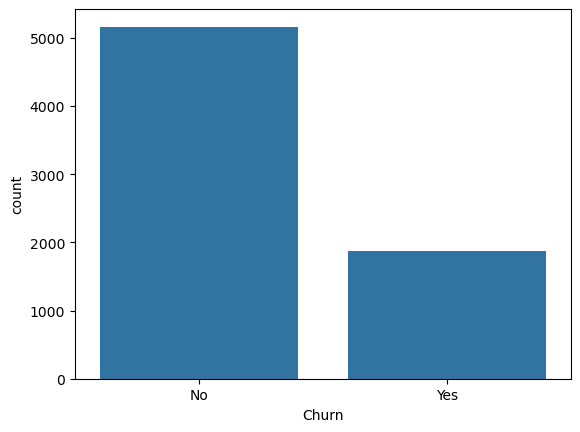

In [45]:
sns.countplot(x= 'Churn', data= df)

<Axes: xlabel='Contract', ylabel='count'>

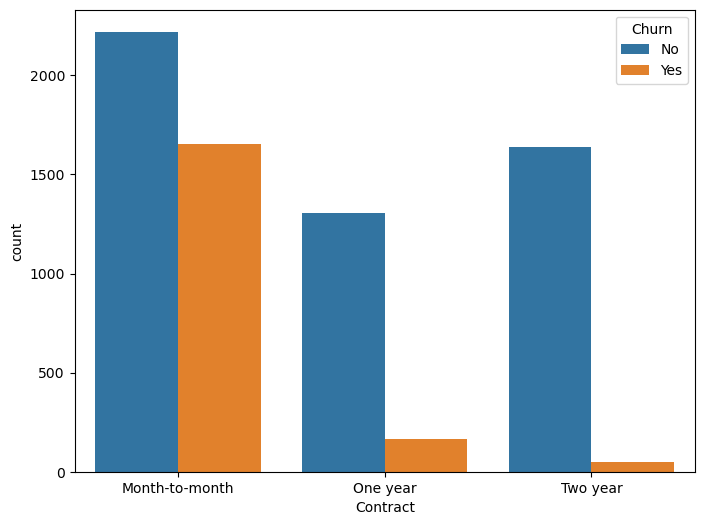

In [49]:
plt.figure(figsize=(8,6))
sns.countplot(x= 'Contract', data= df, hue= 'Churn')

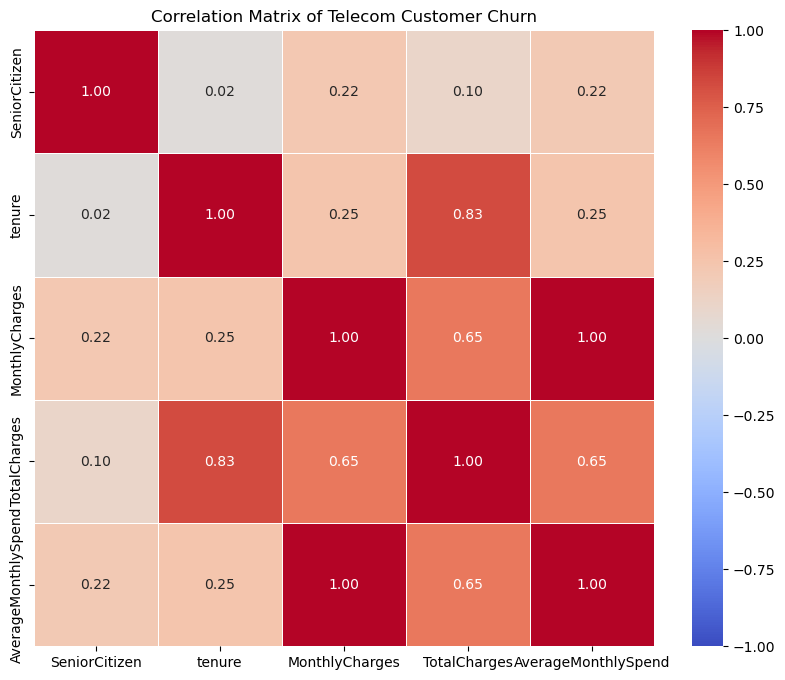

In [50]:
correlation_matrix = df.corr(numeric_only=True)
# Set up the matplotlib figure size
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,         # Add correlation values to each cell
    cmap='coolwarm',    # Use a diverging color palette for positive/negative correlations
    fmt=".2f",          # Format the annotations to two decimal places
    linewidths=.5,      # Add lines between cells
    center=0,           # Ensure 0 (no correlation) is the center of the color scale
    vmin=-1,            # Set the minimum value of the color axis to -1
    vmax=1              # Set the maximum value of the color axis to 1
)

plt.title('Correlation Matrix of Telecom Customer Churn')
plt.show()

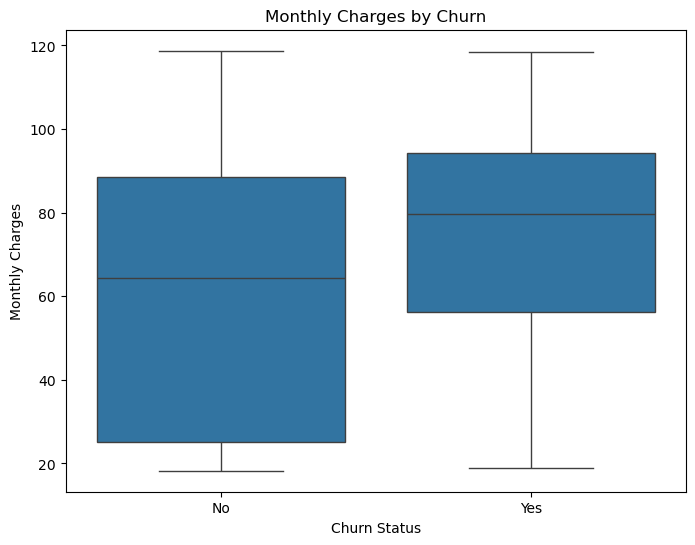

In [51]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')
plt.show()

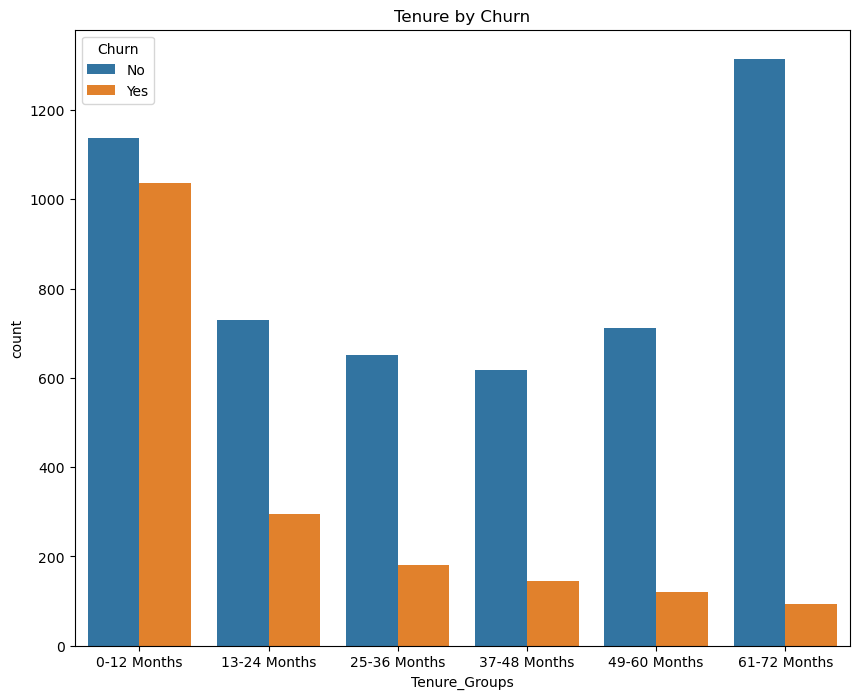

In [55]:
plt.figure(figsize=(10,8))
sns.countplot(x= 'Tenure_Groups', data= df, hue= 'Churn')
plt.title('Tenure by Churn')
plt.show()

In [56]:
# Convert binary yes/no to 1/0

df = df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0,'No phone service':0}) # for replacing yes and no values in entire dataframe

df.head()

C:\Users\ANUSHKA\AppData\Local\Temp\ipykernel_3588\2214501721.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'yes': 1, 'no': 0, 'Yes': 1, 'No': 0,'No phone service':0}) # for replacing yes and no values in entire dataframe


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Groups,AverageMonthlySpend
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,0-12 Months,29.850000
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,0,0,One year,0,Mailed check,56.95,1889.50,0,25-36 Months,55.573529
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,0-12 Months,54.075000
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,37-48 Months,40.905556
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,0-12 Months,75.825000


In [57]:
df.dtypes

customerID               object
gender                   object
SeniorCitizen             int64
Partner                   int64
Dependents                int64
tenure                    int64
PhoneService              int64
MultipleLines             int64
InternetService          object
OnlineSecurity           object
OnlineBackup             object
DeviceProtection         object
TechSupport              object
StreamingTV              object
StreamingMovies          object
Contract                 object
PaperlessBilling          int64
PaymentMethod            object
MonthlyCharges          float64
TotalCharges            float64
Churn                     int64
Tenure_Groups          category
AverageMonthlySpend     float64
dtype: object

In [69]:
# One-hot encode categorical columns like Contract, InternetService
from sklearn.preprocessing import OneHotEncoder

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

df[categorical_columns] = df[categorical_columns].astype(str)

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)


In [ ]:
""" 
Summary:

 * Dataset Overview:
 - Total records: 7,043 customers
 - Features: 21 original columns → 23 after feature engineering
Data types:
      - Numerical: tenure, MonthlyCharges, TotalCharges
      - Categorical: services, contract type, payment method, etc.

 * Data Quality & Preprocessing
 - Missing Values:
   TotalCharges had 11 missing values, which were handled

 - Data Type Correction:
   TotalCharges converted from object → numeric

 - Encoding:
   Binary categorical variables converted (Yes/No → 1/0)

 - Feature Engineering:
    - Created:
        -Tenure_Groups (customer lifecycle segmentation)
        -AverageMonthlySpend

 * Descriptive Statistics Insights
 - Average tenure: ~32 months → moderate customer retention
 - Average monthly charges: ~₹64.76 (approx unit)
 - High variability in tenure and charges → diverse customer base
 - Majority customers are: Non-senior citizens (~84%)

 * Month-to-month contracts show highest churn while Long-term contracts (1-year, 2-year) have lower churn.

 * Customers with: 0-12 months tenure have highest churn, Long-tenure customers are more loyal.

 * Electronic check users have higher churn and Automatic payment methods have lower churn.

 * Fiber optic users have higher churn while DSL users are relatively stable.

 * Key Patterns Identified
 High churn risk segments:
 - New customers (low tenure)
 - Month-to-month contracts
 - High monthly charges
 - Electronic check users

 Low churn segments:
 - Long-term contract customers
 - Customers with support/security services
 - Automatic payment users
 
"""